In [1]:
%cd ../..

/home/jj/Research/ConceptualSensitivityRegularization


In [2]:
import numpy as np
from csr.module.dataset.rrclarc_datasets import get_celeba_biased_dataset


/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
celeba_path = ['/media/disk1/Data/',]
artifact_path = 'configs/dataset/artifacts_celeba.json'

dataset = get_celeba_biased_dataset(
    data_paths=celeba_path,
    normalize_data=True,
    artifact_ids_file=artifact_path
)


Using subset
Chosen attribute Blond_Hair with id 9.
not blonde 14539
overall 20438
Chosen attribute Blond_Hair with id 9.
Using subset
Artifacts in train: 16
Artifacts in test: 90
Artifacts in val: 87


In [4]:
print(dataset.sample_ids_by_artifact.keys())
print([len(dataset.sample_ids_by_artifact[artifact_id]) for artifact_id in dataset.sample_ids_by_artifact.keys()])
print()
print(len(dataset.all_artifact_sample_ids))
print(len(dataset.clean_sample_ids))
print(len(dataset))
print()
print(len(set.intersection(set(dataset.all_artifact_sample_ids), set(dataset.idxs_val))))
print(len(set.intersection(set(dataset.all_artifact_sample_ids), set(dataset.idxs_test))))
print(len(set.intersection(set(dataset.all_artifact_sample_ids), set(dataset.idxs_train))))
print(len(set.intersection(set(dataset.clean_sample_ids), set(dataset.idxs_val))))
print(len(set.intersection(set(dataset.clean_sample_ids), set(dataset.idxs_test))))
print(len(set.intersection(set(dataset.clean_sample_ids), set(dataset.idxs_train))))
print()
print(len(np.intersect1d(dataset.all_artifact_sample_ids, dataset.idxs_val)))





dict_keys(['blonde_collar', 'not_blonde_collar'])
[193, 1497]

1690
31790
33480

235
217
1238
3182
3200
25408

235


In [5]:
from torchvision.datasets import CelebA
ds = CelebA(
    root = '/media/disk1/Data/',
    split = 'all',
)

In [6]:
ATTR = "Blond_Hair"
ATTR2 = "Wearing_Necktie"
attr_id = np.where(np.array(ds.attr_names) == ATTR)[0][0]
attr_id2 = np.where(np.array(ds.attr_names) == ATTR2)[0][0]
USE_SUBSET = True
if USE_SUBSET:
    print("Using subset")
    NTH = 10
else:
    NTH = 1
filter_indices = np.zeros(len(ds.attr))


filter_indices[::NTH] = 1
print(f"Chosen attribute {ATTR} with id {attr_id}.")
labels = ds.attr[:, attr_id]
labels2 = ds.attr[:, attr_id2]
both = np.where(np.logical_and(labels, labels2) == 1)[0]
# print(both)
filter_indices[both] = 1

both_names = np.array(ds.filename)[both]
# print("', '".join(both_names) + "\n")

labels_not_blonde = 1 * (ds.attr[:, attr_id] == 0)
labels_collar = ds.attr[:, attr_id2]
not_blonde_collar = np.where(
    np.logical_and(labels_not_blonde, labels_collar) == 1
)[0]
print("not blonde", len(not_blonde_collar))
print("overall", np.sum(filter_indices == 1))
filter_indices[not_blonde_collar] = 1

labels = ds.attr[:, attr_id][filter_indices == 1]
labels2 = ds.attr[:, attr_id2][filter_indices == 1]
both = np.where(np.logical_and(labels, labels2) == 1)[0]
# print(both[:10])

labels_not_blonde = 1 * (ds.attr[:, attr_id][filter_indices == 1] == 0)
labels_collar = ds.attr[:, attr_id2][filter_indices == 1]
not_blonde_collar = np.where(
    np.logical_and(labels_not_blonde, labels_collar) == 1
)[0]

print(f"Chosen attribute {ATTR} with id {attr_id}.")

Using subset
Chosen attribute Blond_Hair with id 9.
not blonde 14539
overall 20438
Chosen attribute Blond_Hair with id 9.


In [7]:
dataset.metadata

,image_id,targets,blonde_collar
0,000001.jpg,0,False
1,000011.jpg,0,False
2,000015.jpg,0,False
3,000021.jpg,0,False
4,000031.jpg,0,False
...,...,...,...
33475,202571.jpg,0,False
33476,202581.jpg,0,False
33477,202586.jpg,0,False
33478,202588.jpg,0,False


In [8]:
dataset.metadata['targets'].value_counts()

targets
0    30300
1     3180
Name: count, dtype: int64

In [9]:
dataset.metadata['blonde_collar'].value_counts()

blonde_collar
False    33287
True       193
Name: count, dtype: int64

In [10]:
dataset.idxs_train

array([    1,     2,     3, ..., 33477, 33478, 33479])

In [11]:
dset_tr = dataset.get_subset_by_idxs(dataset.idxs_train)

In [12]:
dset_tr.metadata

,image_id,targets,blonde_collar
0,000011.jpg,0,False
1,000015.jpg,0,False
2,000021.jpg,0,False
3,000031.jpg,0,False
4,000032.jpg,0,False
...,...,...,...
26641,202561.jpg,0,False
26642,202571.jpg,0,False
26643,202586.jpg,0,False
26644,202588.jpg,0,False


In [13]:
def unnormalize(img):
    return img.permute(1,2,0) * 0.5 + 0.5


In [14]:
dset_tr.metadata

,image_id,targets,blonde_collar
0,000011.jpg,0,False
1,000015.jpg,0,False
2,000021.jpg,0,False
3,000031.jpg,0,False
4,000032.jpg,0,False
...,...,...,...
26641,202561.jpg,0,False
26642,202571.jpg,0,False
26643,202586.jpg,0,False
26644,202588.jpg,0,False


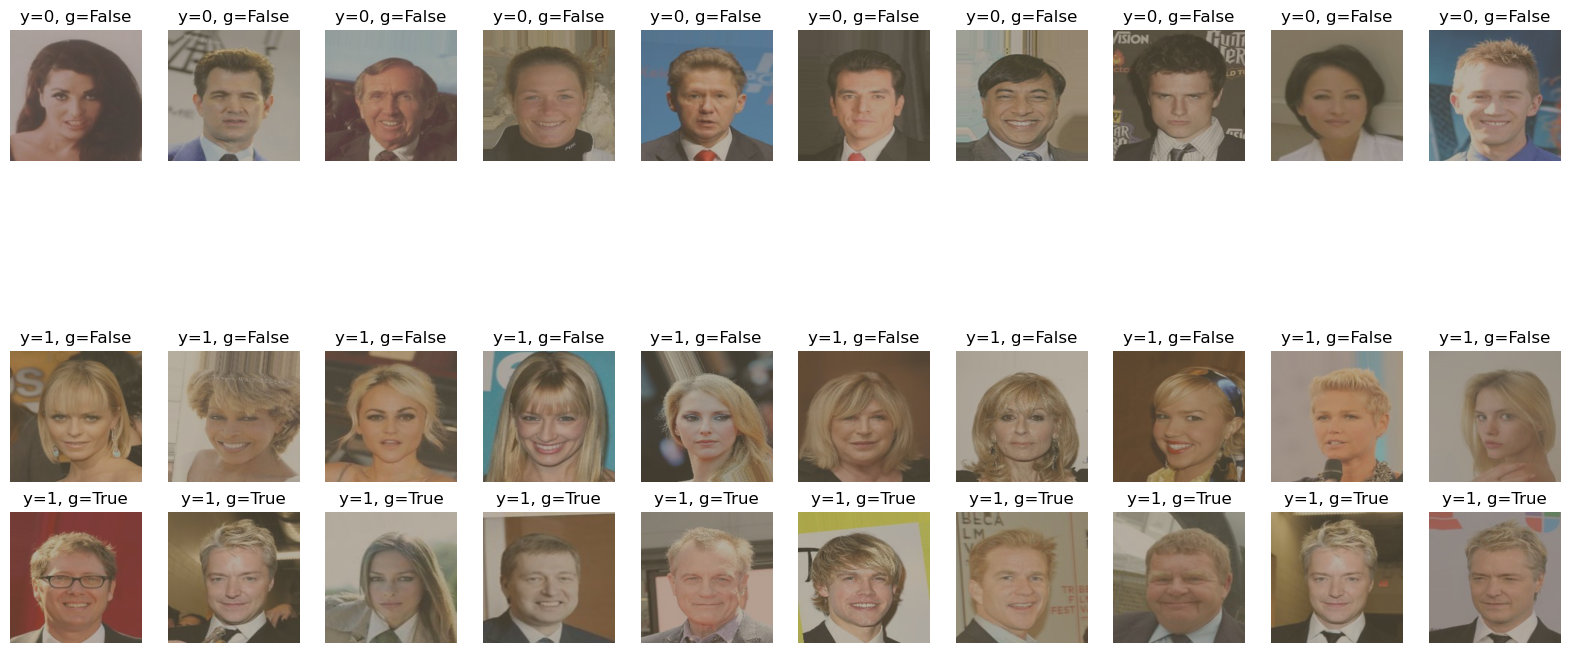

In [39]:
# plot some images in dataset_dict
from itertools import product
import matplotlib.pyplot as plt
import torchvision

fig, ax = plt.subplots(4, 10, figsize=(20, 8))

for tmp in [[0, 0], [0, 1], [1, 0], [1, 1]]:
    blonde_collar, targets = tmp
    row = targets * 2 + blonde_collar
    for col in range(10):
        idxs = dset_tr.metadata.query(f"targets == {targets} and blonde_collar == {blonde_collar}").index
        if len(idxs) == 0:
            continue

        img, label, g, _ = dset_tr[idxs[col]]
        ax[row, col].imshow(unnormalize(img))
        ax[row, col].set_title(f'y={label}, g={g}')
        ax[row, col].axis('off')

for row, col in product(range(4), range(10)):
    if ax[row, col].get_title() == '':
        ax[row, col].axis('off')
plt.show()

In [16]:
from csr.module import DataModule

dm = DataModule(
    dataset='celeba_collar_concepts',
    data_type='raw',
    data_dir='/media/disk1/Data/celeba',
    model='convnext_t',
    module_name='ERM'
)
dm.setup()
tr_loader= dm.train_dataloader()

In [17]:
import torch
def unnormalize(img):
    # ImageNet unnormalization
    imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).reshape(1,1,-1)
    imagenet_std = torch.tensor([0.229, 0.224, 0.225]).reshape(1,1,-1)
    return img.permute(1,2,0) * imagenet_std + imagenet_mean

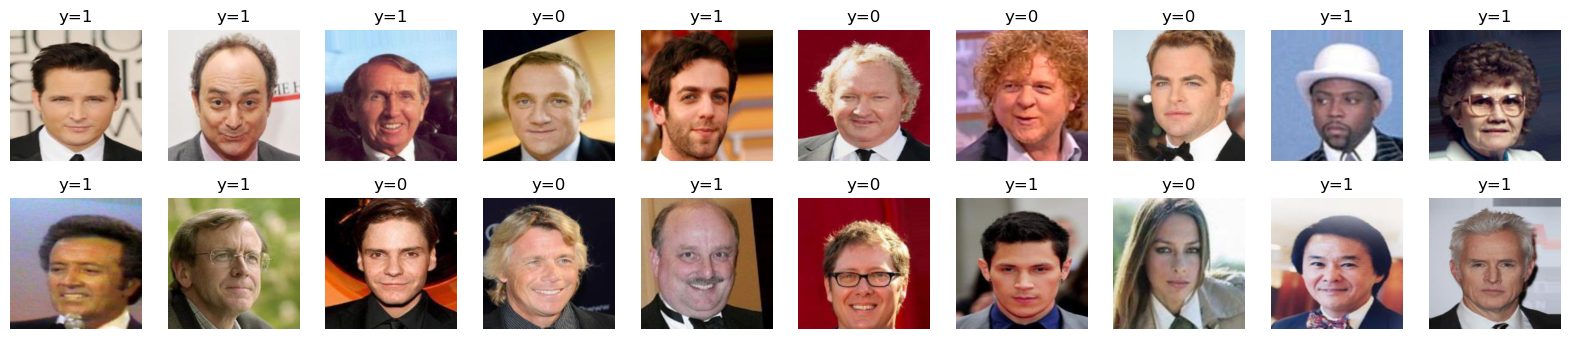

In [18]:
# plot images from the dataloader, with a title of the label
fig, ax = plt.subplots(2, 10, figsize=(20, 4))

img, label, _, _ = next(iter(tr_loader))

for row in range(2):
    for col in range(10):
        no = row * 10 + col
        ax[row, col].imshow(unnormalize(img[no]))
        ax[row, col].set_title(f'y={label[no]}')
        ax[row, col].axis('off')

---


In [19]:
%cd ../..

/home/jj


In [20]:
from csr.module import DataModule


In [36]:
dm = DataModule(
    dataset='celeba_collar',
    data_type='feature',
    data_dir='/media/disk2/Data',
    model='convnext_t',
    minor_ratio = 0.05
)

In [37]:
dm.setup()
dm.prepare_data()

tr {(0, 0): tensor(24235), (0, 1): tensor(2395), (1, 0): tensor(0), (1, 1): tensor(16)}
va {(0, 0): tensor(6090), (0, 1): tensor(570), (1, 0): tensor(0), (1, 1): tensor(174)}
te {(0, 0): tensor(6040), (0, 1): tensor(614), (1, 0): tensor(0), (1, 1): tensor(180)}


In [23]:
dm = DataModule(
    dataset='catdog',
    data_type='feature',
    data_dir='/media/disk2/Data',
    model='convnext_t',
    minor_ratio = 0.05
)

In [24]:
dm.setup()
dm.prepare_data()

tr {(0, 0): tensor(1465), (0, 1): tensor(151), (1, 0): tensor(71), (1, 1): tensor(3027)}
va {(0, 0): tensor(190), (0, 1): tensor(388), (1, 0): tensor(194), (1, 1): tensor(411)}
te {(0, 0): tensor(480), (0, 1): tensor(998), (1, 0): tensor(480), (1, 1): tensor(998)}


In [25]:
dm.train_dataset.y

tensor([0, 0, 0,  ..., 1, 1, 1])

In [26]:
dm.train_dataset.g

tensor([0, 0, 0,  ..., 1, 1, 1])

In [27]:
import pandas as pd

# y and g
df = pd.DataFrame({
    'y': dm.train_dataset.y,
    'g': dm.train_dataset.g
})


In [28]:
df.groupby(['y', 'g']).size()

y  g
0  0    1465
   1      71
1  0     151
   1    3027
dtype: int64

In [29]:
dm = DataModule(
    dataset='celeba_collar',
    data_type='raw',
    data_dir='/media/disk1/Data',
    module_name='FeatureGenerator'
)
dm.setup()
dm.prepare_data()

Using subset
Chosen attribute Blond_Hair with id 9.
not blonde 14539
overall 20438
Chosen attribute Blond_Hair with id 9.
Using subset
Artifacts in train: 16
Artifacts in test: 90
Artifacts in val: 87


In [30]:
dm.train_dataset.metadata

,image_id,targets,blonde_collar
0,000011.jpg,0,False
1,000015.jpg,0,False
2,000021.jpg,0,False
3,000031.jpg,0,False
4,000032.jpg,0,False
...,...,...,...
26641,202561.jpg,0,False
26642,202571.jpg,0,False
26643,202586.jpg,0,False
26644,202588.jpg,0,False


In [31]:
dm.train_dataset.metadata.groupby(['targets', 'blonde_collar']).size()

targets  blonde_collar
0        False            24235
1        False             2395
         True                16
dtype: int64

In [32]:
# loop over training dataloader
for batch in dm.train_dataloader():
    x, y, g, _ = batch
    break

/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(
/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/transforms/functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change f

In [33]:
g

tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False, False,
        False, False])

In [34]:
path = '/media/disk2/Data/Features/celeba_collar/convnext_t/tr'
import torch
dat1 = torch.load(f'{path}/0.pt')
dat2 = torch.load(f'{path}/1.pt')
meta = torch.load(f'{path}/metadata.pt')
df = pd.DataFrame(meta).transpose()
df.columns = ['targets', 'blonde_collar', 'idx']

df['targets'] = df['targets'].astype(int)
df['blonde_collar'] = df['blonde_collar'].astype(int)
df.groupby(['targets', 'blonde_collar']).size()

targets  blonde_collar
0        0                24235
1        0                 2395
         1                   16
dtype: int64

In [35]:
path = '/media/disk2/Data/Features/catdog/convnext_t/tr'
import torch
dat1 = torch.load(f'{path}/0.pt')
dat2 = torch.load(f'{path}/1.pt')
meta = torch.load(f'{path}/metadata.pt')
df = pd.DataFrame(meta).transpose()
df.columns = ['targets', 'blonde_collar', 'idx']

df['targets'] = df['targets'].astype(int)
df['blonde_collar'] = df['blonde_collar'].astype(int)
df.groupby(['targets', 'blonde_collar']).size()

targets  blonde_collar
0        0                1465
         1                  71
1        0                 151
         1                3027
dtype: int64